# Synthetic Regime Shift: Topological Drift vs. Statistical Drift

Stage 1 experiment from `paper_notes/research_brief.md`

Goal: show that topological attractor drift detects structural regime changes that ordinary statistics (mean, variance, autocorrelation, spectral distance) miss, under a synthetic shift with matched first-order moments.

The canonical implementation lives in `synthetic_regime_shift.py` (run via `uv run python experiments/synthetic_regime_shift.py` for a repeatable CLI run). This notebook imports that module directly so the two never drift apart; it exists only to present the figure and metrics table inline.

## 1. Setup

In [1]:
import sys
from pathlib import Path

from IPython.display import Image

NOTEBOOK_DIR = Path.cwd()
sys.path.append(str(NOTEBOOK_DIR))
sys.path.append(str(NOTEBOOK_DIR / ".." / "src"))

from synthetic_regime_shift import (
    build_metrics_table,
    compute_baseline_drifts,
    compute_topological_drift,
    generate_sine_to_quasiperiodic,
    plot_results,
)

## 2. Generate synthetic regime-shift series

Periodic -> quasi-periodic shift, normalized so the pre/post-shift segments share approximately the same mean and variance, isolating topology as the distinguishing signal.

In [2]:
window = 128
stride = 8

series, shift_index = generate_sine_to_quasiperiodic()
source_window = series[:window]
shift_index

700

## 3. Baseline statistical drift signals

Rolling mean, rolling variance, autocorrelation distance, FFT/periodogram distance — the non-topological baselines from research brief section 8/9.

In [3]:
times, drifts = compute_baseline_drifts(
    series=series,
    source_window=source_window,
    window=window,
    stride=stride,
)
list(drifts.keys())

['Rolling mean drift',
 'Rolling variance drift',
 'Autocorrelation drift',
 'Spectral drift']

## 4. Topological drift signal

Build a source-regime prototype from pre-shift data, then score each sliding window's persistence diagram against it via `TamicSignal`.

In [4]:
topo_drift = compute_topological_drift(
    series=series,
    source_window=source_window,
    window=window,
    stride=stride,
)
topo_drift[:5], topo_drift[-5:]

(array([0.        , 0.        , 0.01266471, 0.01200359, 0.02123105]),
 array([2.10457769, 1.96871555, 2.35083617, 2.36917201, 2.38880294]))

## 5. Comparison plot (Figure 1)

Overlay topological drift against the statistical baselines and the known shift boundary, per research brief section 11 (Figure 1 description).

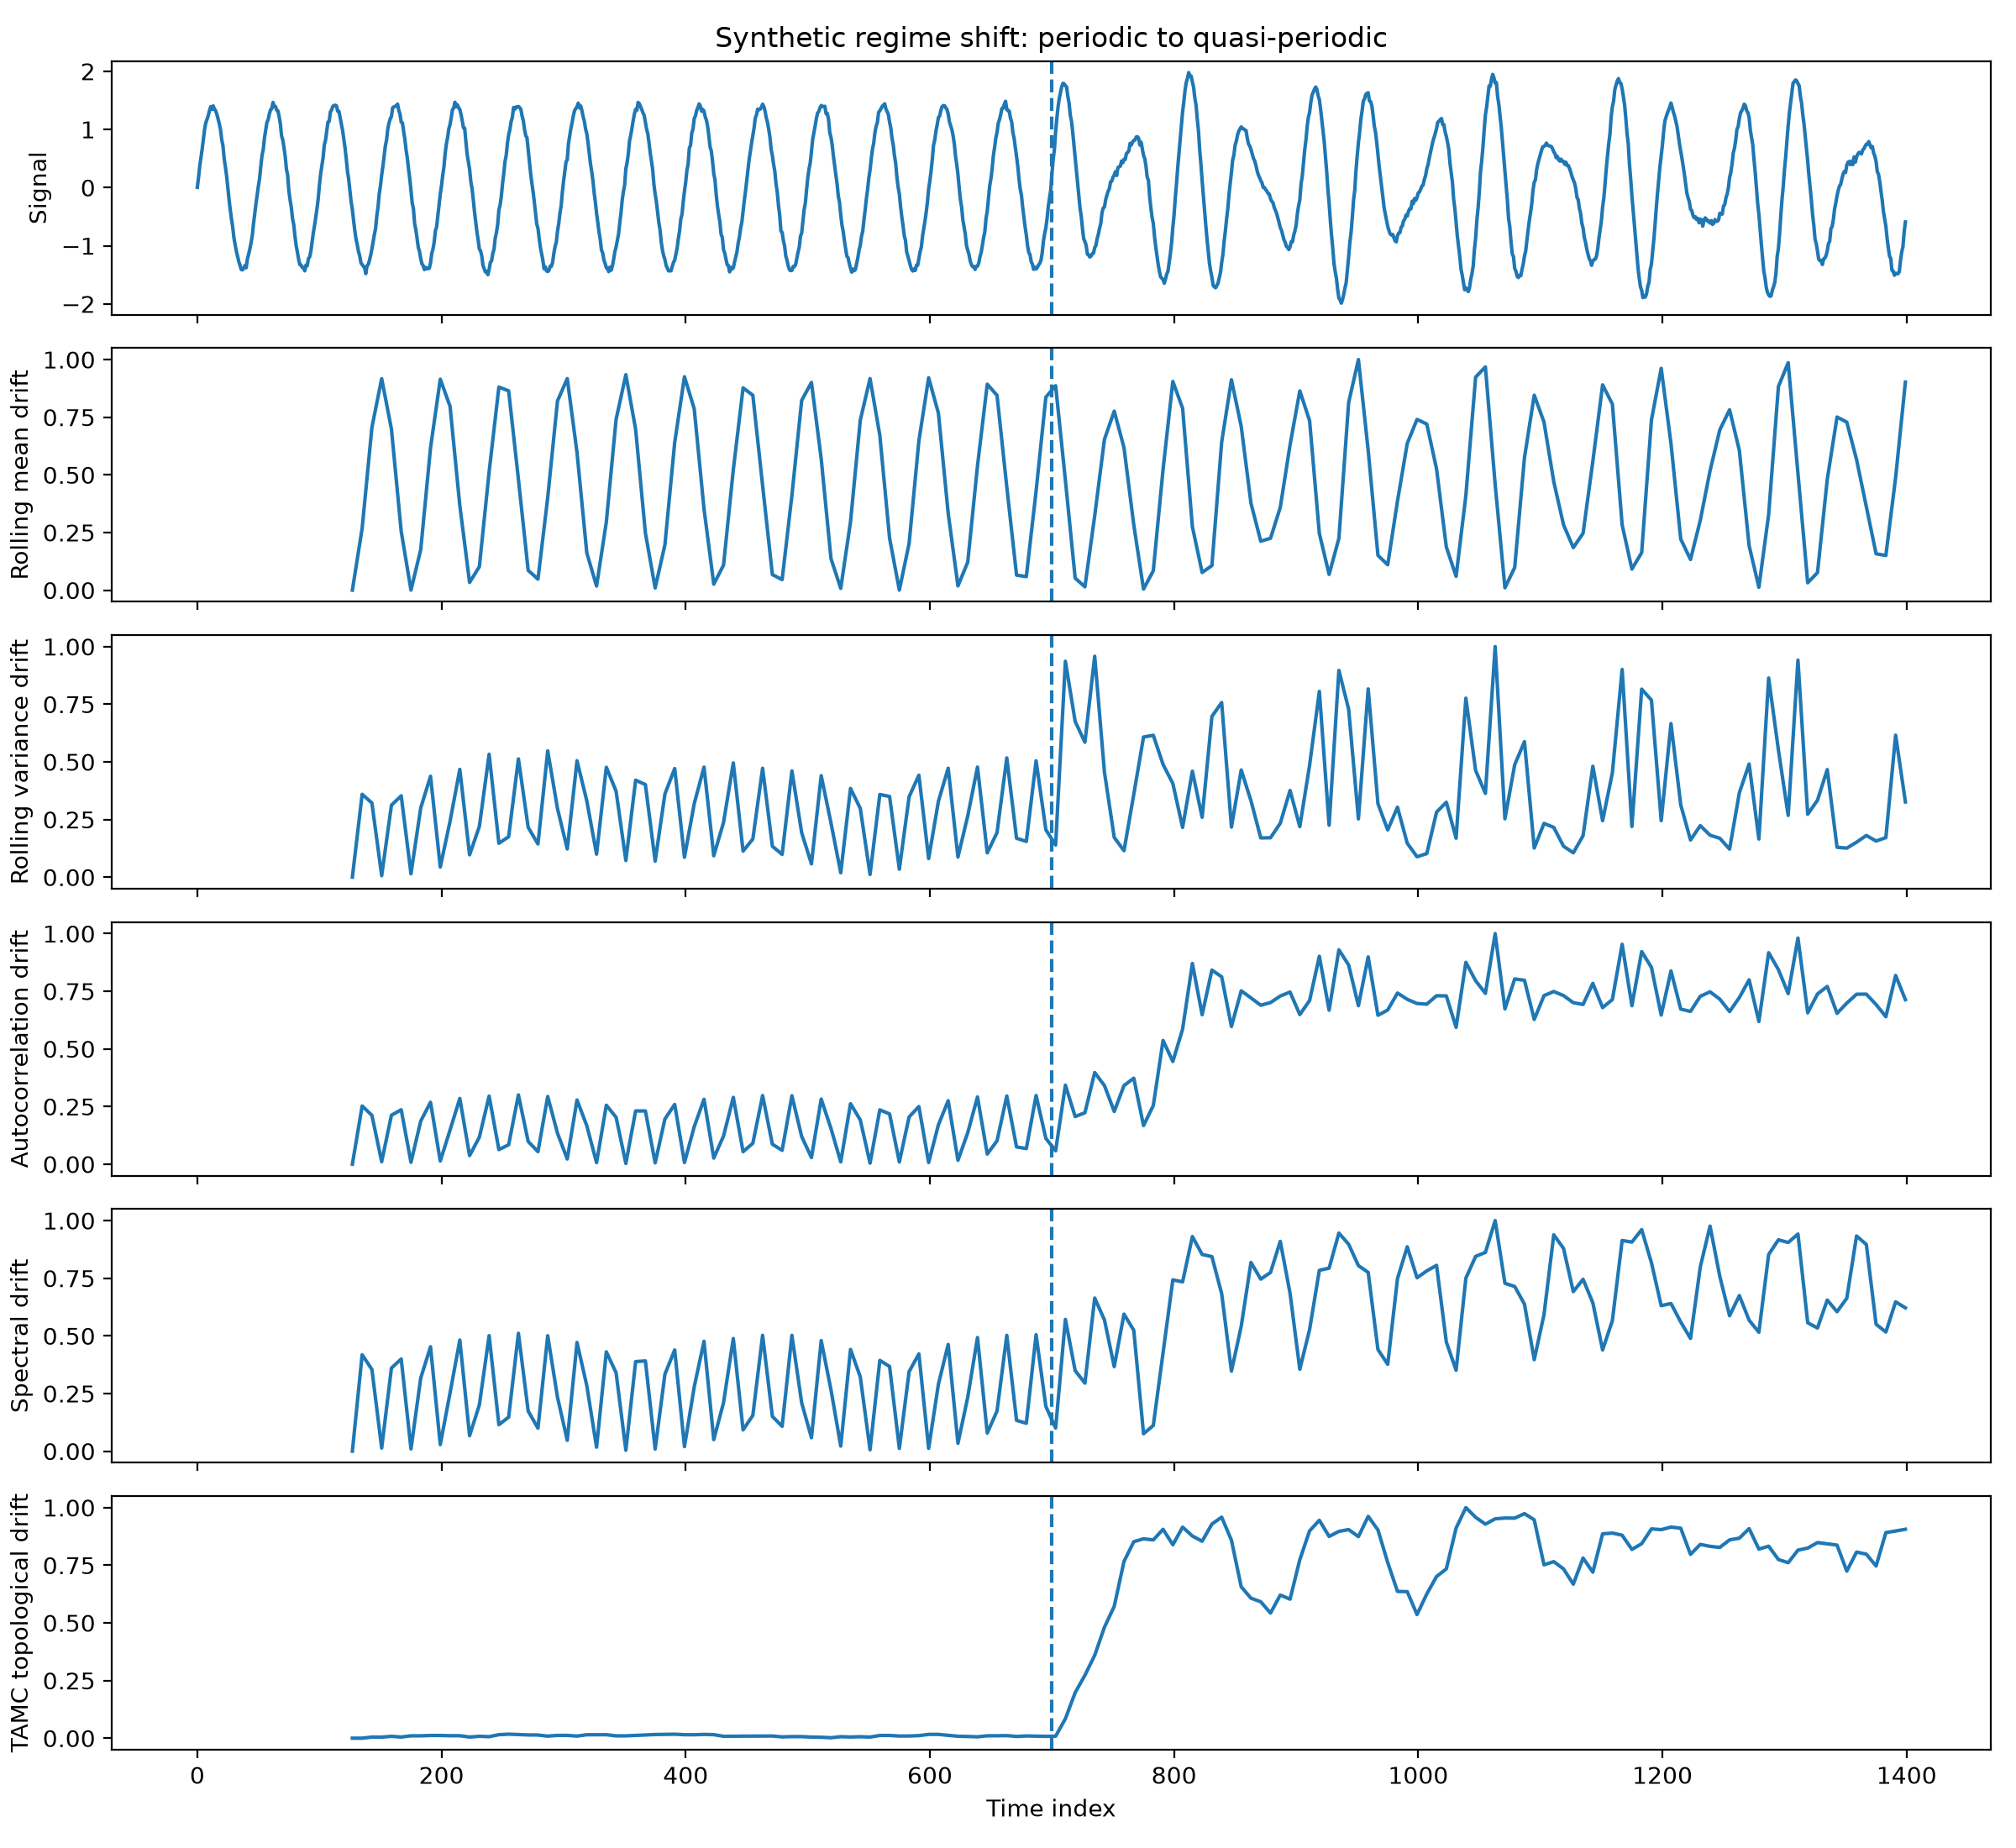

In [5]:
output_path = NOTEBOOK_DIR / ".." / "figures" / "synthetic_regime_shift_drift.png"
plot_results(
    series=series,
    times=times,
    shift_index=shift_index,
    drifts=drifts,
    topological_drift=topo_drift,
    output_path=output_path,
)
Image(filename=str(output_path))

## 6. Detection metrics

Detection delay, false alarm rate, AUROC for the shift boundary, per research brief section 8 metrics list. Threshold for each signal is `pre_mean + 3 * pre_std`, set from the pre-shift segment only.

In [6]:
all_signals = {**drifts, "TAMC topological drift": topo_drift}
metrics_table = build_metrics_table(times, all_signals, shift_index)
metrics_table

,Pre Mean,Pre Std,Post Mean,Max Post,Delay,False Alarms,AUROC
Rolling mean drift,0.172078,0.122031,0.174465,0.372749,NaN,0.0,0.508681
Rolling variance drift,0.046159,0.028251,0.067769,0.171844,11.0,0.0,0.631787
Autocorrelation drift,0.230016,0.161405,1.041323,1.532567,91.0,0.0,0.971907
Spectral drift,0.118648,0.081939,0.309941,0.463948,115.0,0.0,0.930871
TAMC topological drift,0.026401,0.010870,2.060300,2.636707,11.0,0.0,0.992740
